LAB 7: Cepstral Analysis of Speech Signal

In [ ]:
pip install numpy scipy matplotlib librosa

Upload your audio file

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving my_voice.m4a to my_voice.m4a


Convert .m4a → .wav

In [ ]:
!apt-get install ffmpeg -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
import os

input_file = list(uploaded.keys())[0]
output_file = "speech.wav"

# Convert to wav
!ffmpeg -i "$input_file" -ac 1 -ar 16000 "$output_file"

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

Load and select frame

In [ ]:
signal, sr = librosa.load("speech.wav", sr=None)

# Take 20 ms frame
frame_length = int(0.02 * sr)
frame = signal[:frame_length]

print("Sampling Rate:", sr)

Sampling Rate: 16000


Compute Real Cepstrum

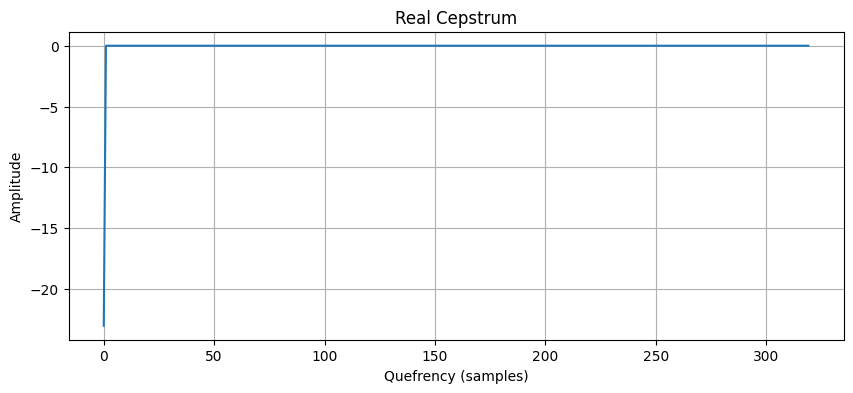

In [ ]:
# FFT
spectrum = np.fft.fft(frame)

# Log magnitude
log_mag = np.log(np.abs(spectrum) + 1e-10)

# Cepstrum
cepstrum = np.fft.ifft(log_mag).real

# Plot
plt.figure(figsize=(10,4))
plt.plot(cepstrum)
plt.title("Real Cepstrum")
plt.xlabel("Quefrency (samples)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

Pitch Detection (5 ms to 20 ms)

In [ ]:
min_q = int(0.005 * sr)
max_q = int(0.02 * sr)

cep_range = cepstrum[min_q:max_q]

peak_index = np.argmax(cep_range) + min_q

pitch_period = peak_index / sr
pitch_freq = 1 / pitch_period

print("Pitch Period:", pitch_period, "seconds")
print("Pitch Frequency:", pitch_freq, "Hz")

Cepstral Filtering (Liftering)

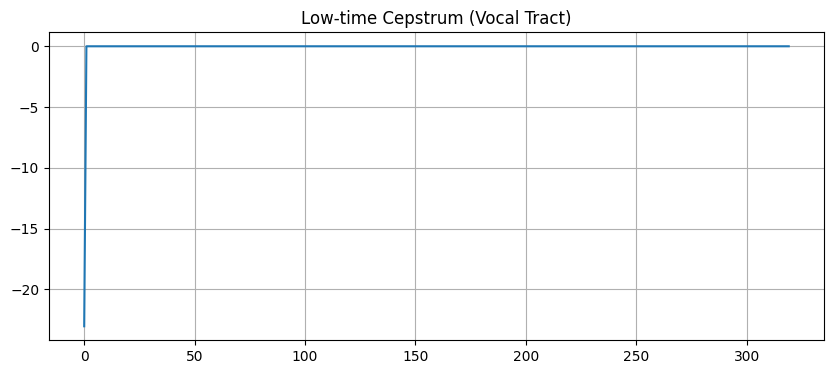

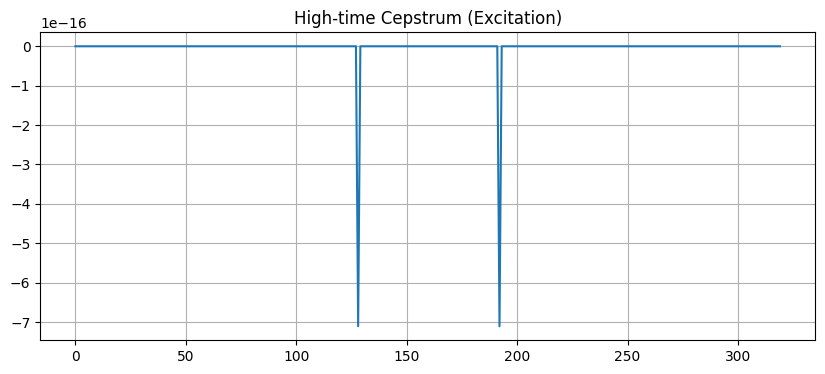

In [ ]:
lifter = np.zeros_like(cepstrum)

# Low-time (vocal tract)
lifter[:30] = 1
low_cepstrum = cepstrum * lifter

# High-time (excitation)
high_cepstrum = cepstrum.copy()
high_cepstrum[:30] = 0

# Plot
plt.figure(figsize=(10,4))
plt.plot(low_cepstrum)
plt.title("Low-time Cepstrum (Vocal Tract)")
plt.grid()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(high_cepstrum)
plt.title("High-time Cepstrum (Excitation)")
plt.grid()
plt.show()